In [21]:
import pandas as pd

data = pd.read_csv("./data/clean/RO_data.csv")
data["Date"] = pd.to_datetime(data["Date"])
data

,ALIMENTATION - Débit (m3/h),ALIMENTATION - Débit (m3/h) PX,ALIMENTATION - Pression HP (bar),PERMEAT - Conductivité (µS/cm),PERMEAT - Débit (m3/h),PERMEAT - Pression Sortie (bar),Rack,Date
0,522.72,422.29,61.60,210.6,419.75,60.51,Rack A,2024-02-19
1,523.49,421.99,61.58,209.2,419.80,60.55,Rack A,2024-02-20
2,522.93,425.20,61.53,209.7,424.03,60.43,Rack A,2024-02-21
3,524.00,421.38,61.51,211.1,419.70,60.48,Rack A,2024-02-22
4,522.66,422.85,61.33,208.0,420.70,60.31,Rack A,2024-02-24
...,...,...,...,...,...,...,...,...
1039,520.00,423.00,61.67,275.0,419.00,60.50,Rack D,2025-01-23
1040,521.00,422.00,61.76,279.0,418.00,60.59,Rack D,2025-01-25
1041,521.00,422.00,61.76,279.0,418.00,60.59,Rack D,2025-01-26
1042,521.00,422.00,61.76,279.0,418.00,60.59,Rack D,2025-01-27


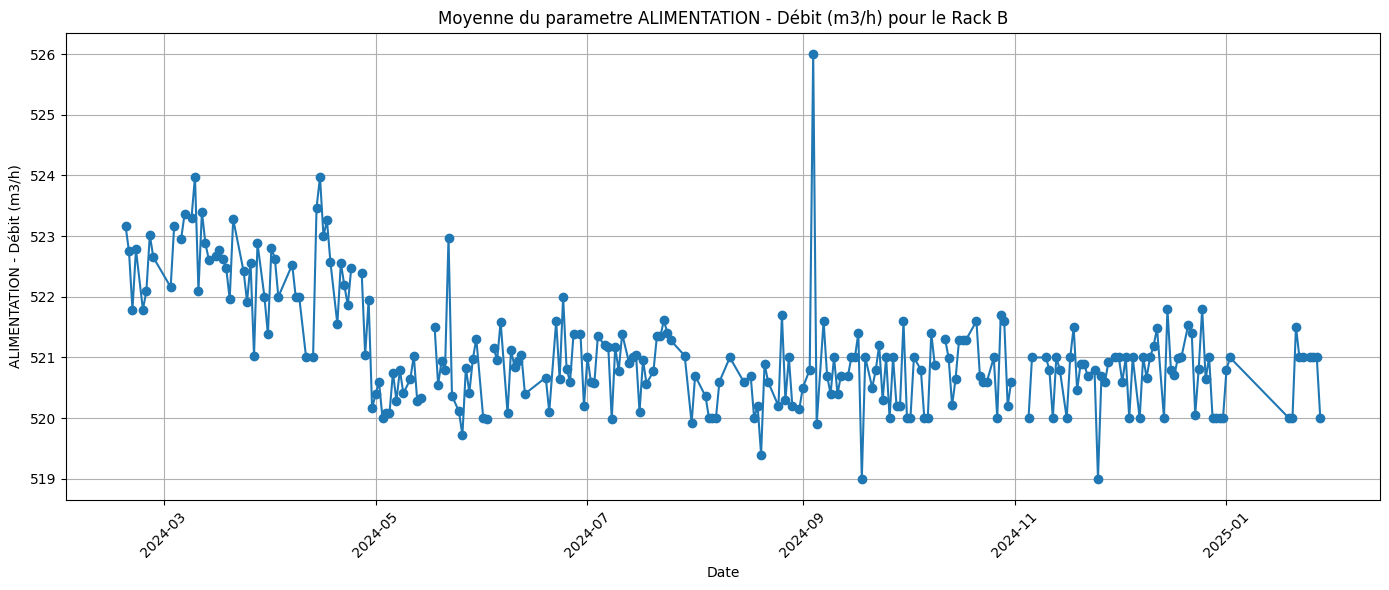

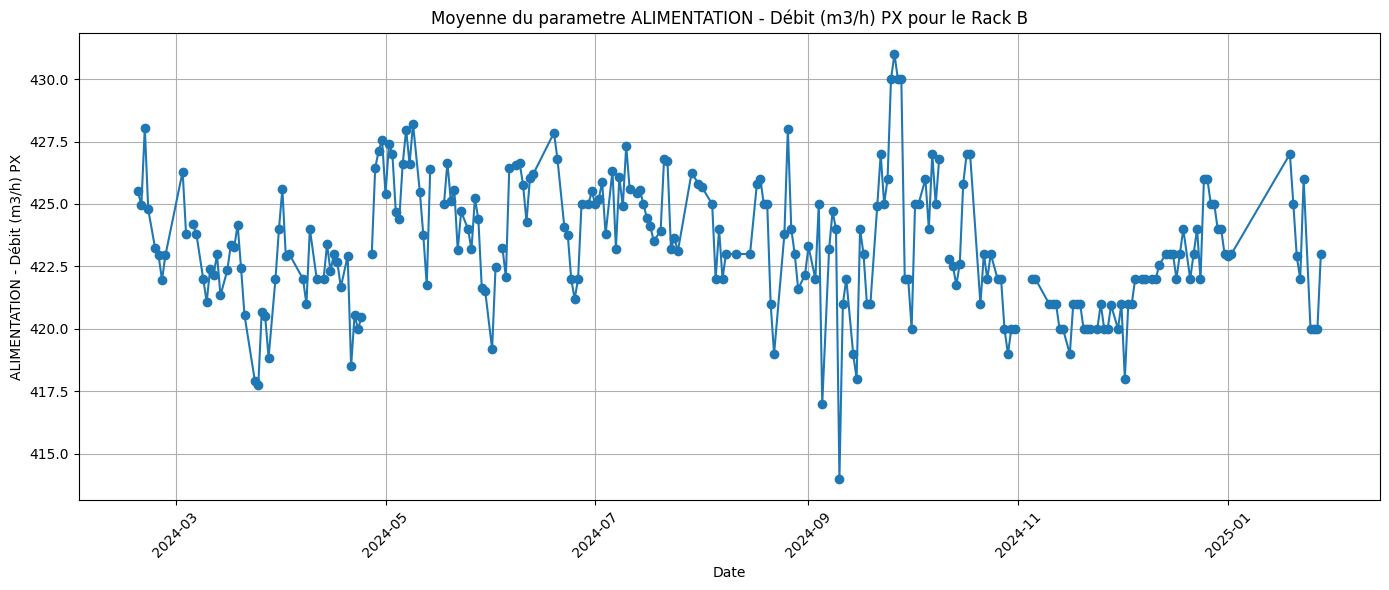

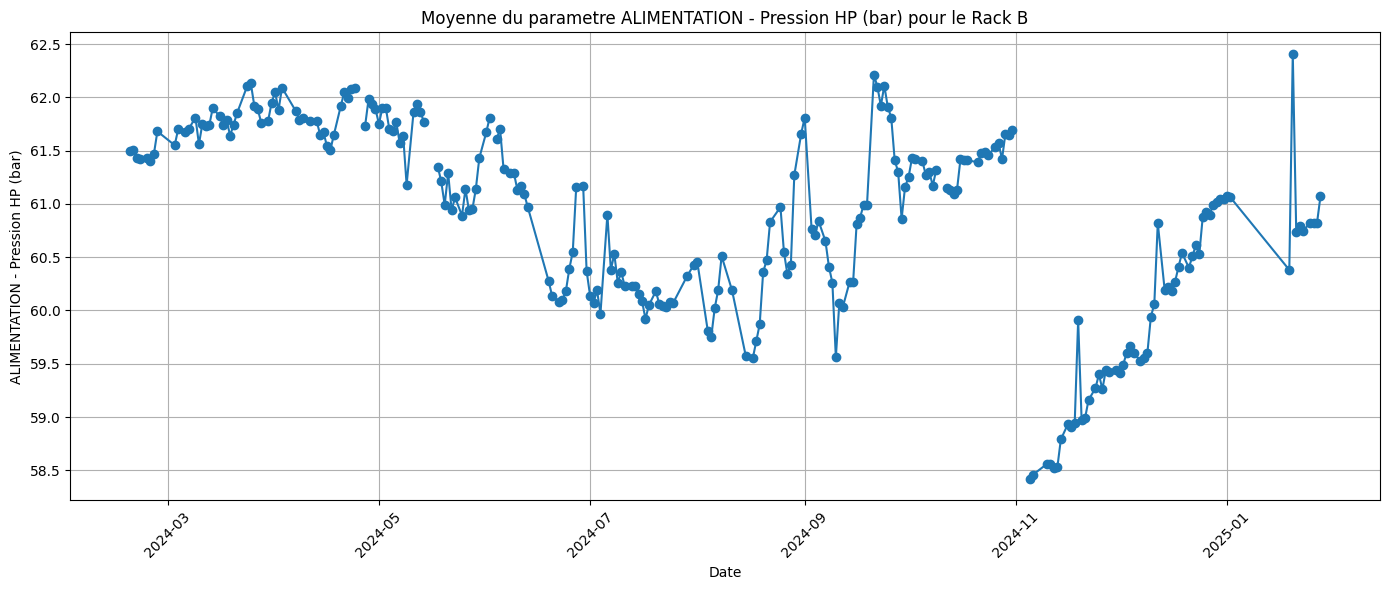

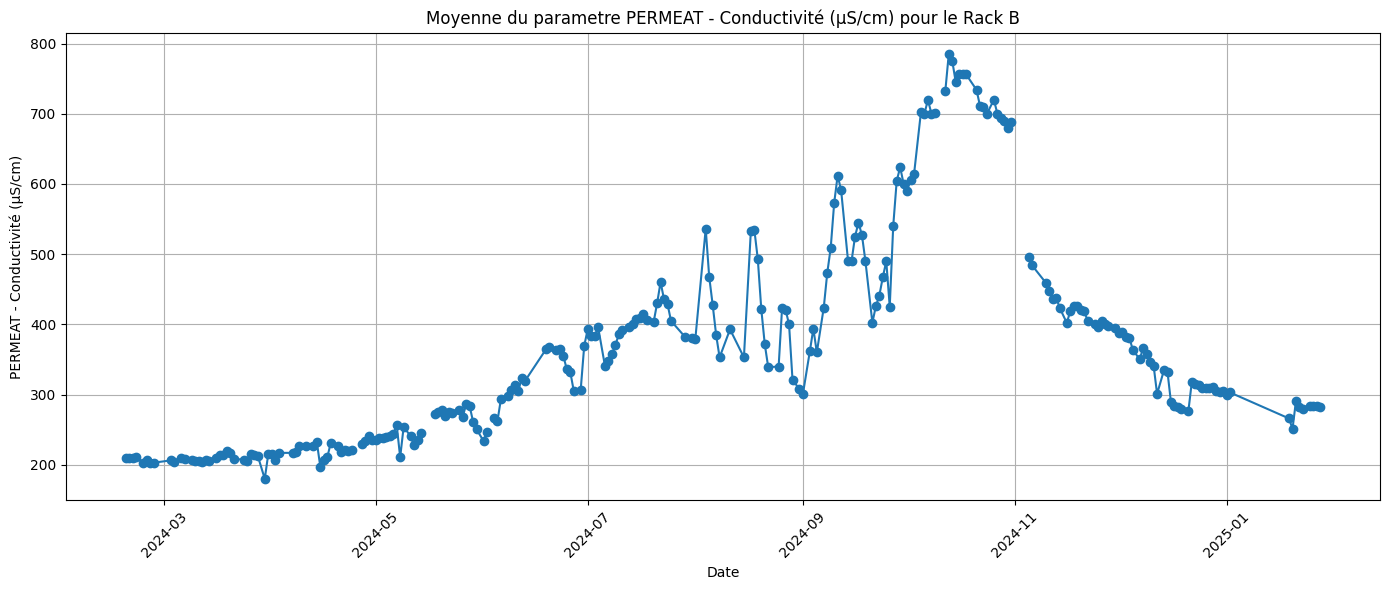

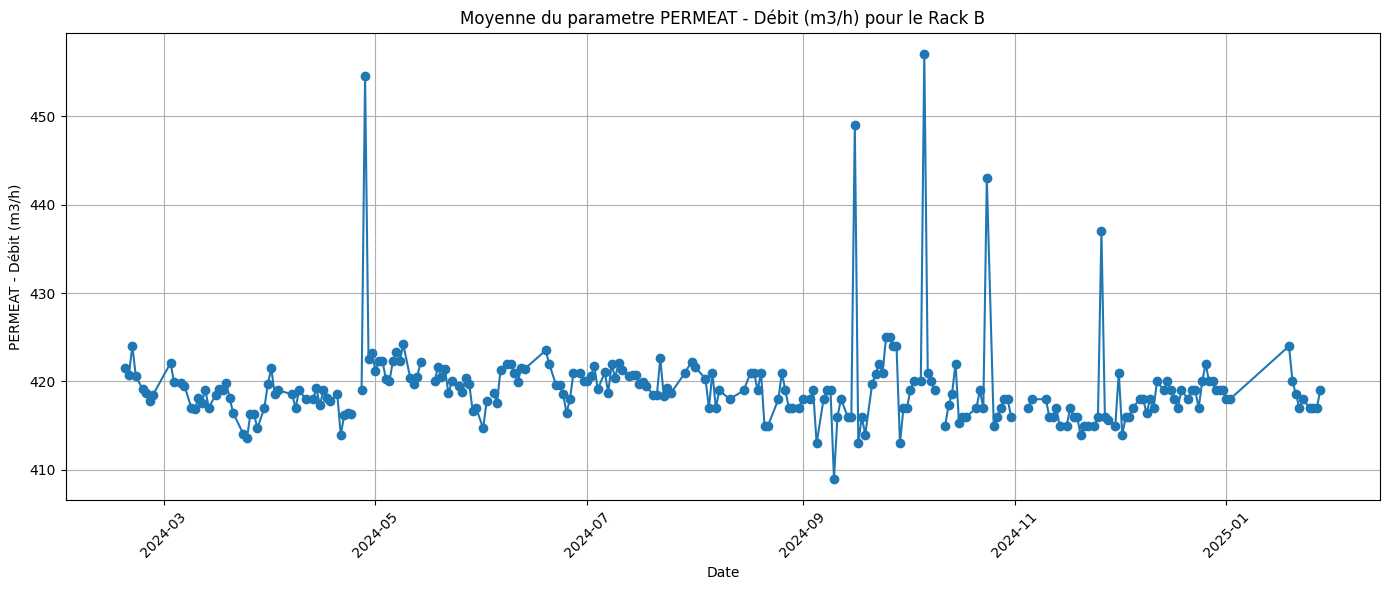

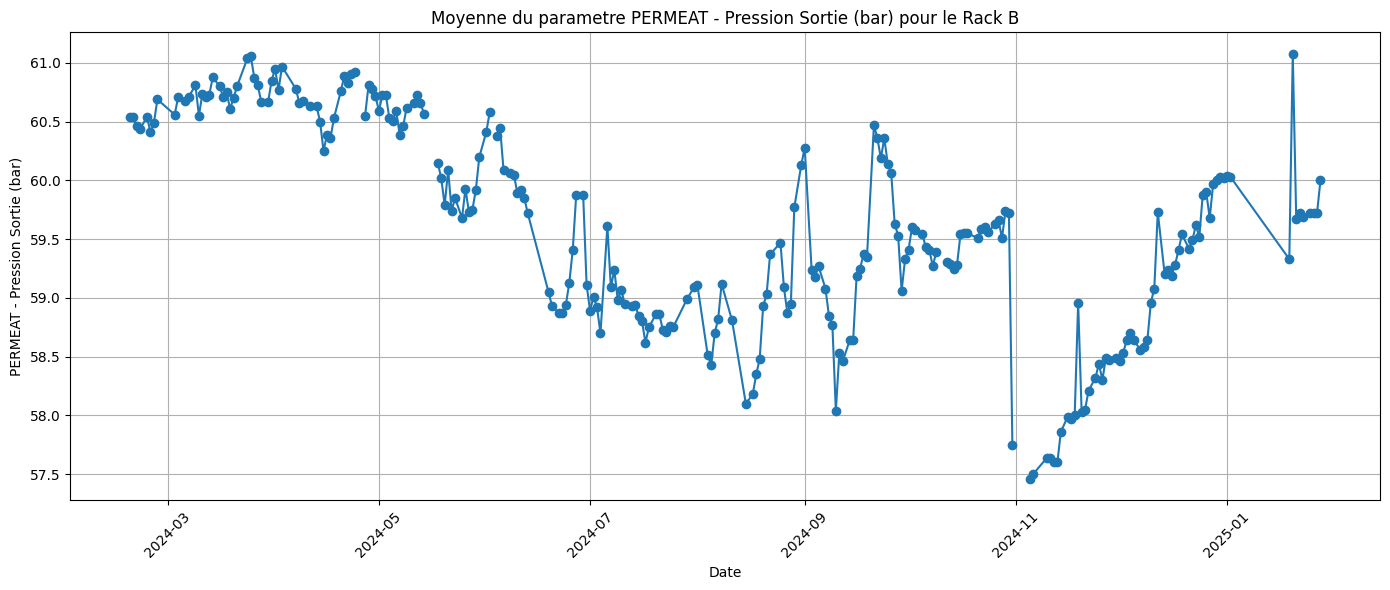

In [24]:
rack_selected = "Rack B"

data_selected = data[data["Rack"] == rack_selected]
data_selected = data_selected.drop(columns=["Rack"])

# build plots for rack A
import matplotlib.pyplot as plt
import seaborn as sns

for col in data_selected.columns:
    if col != 'Date':
        plt.figure(figsize=(14, 6))
        plt.plot(data_selected['Date'], data_selected[col], marker='o')
        plt.title(f'Moyenne du parametre {col} pour le {rack_selected}')
        plt.xlabel('Date')
        plt.ylabel(col)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.grid()
        # replace / in name of the columns
        col_name = col.replace('/', '_')
        plt.savefig(f'./results/RO_eda/plots/{col_name}_{rack_selected}.png')
        plt.show()

In [23]:
# stats descriptive for each rack

# change the index and save to excel
index_french = {
    'count': 'Nombre de valeurs',
    'mean': 'Moyenne',
    'std': 'Ecart-type',
    'min': 'Minimum',
    '25%': '1er quartile',
    '50%': 'Médiane',
    '75%': '3ème quartile',
    'max': 'Maximum'
}

rack_values = data["Rack"].unique()
for rack in rack_values:
    filtered_data = data[data["Rack"] == rack]
    stats_desc = filtered_data.drop(columns=["Rack", "Date"]).describe().rename(index = index_french)
    stats_desc.to_excel(f'./results/RO_eda/tables/RO_{rack}_stats.xlsx')